# Diabetes Risk Digital Twin: Stages 1, 2, and 3

This notebook keeps the complete implemented research path in one shareable file:

- **Stage 1 / RQ1:** Can patient survey data predict Low, Medium (prediabetes), and High (diabetes) risk?
- **Stage 2 / RQ2:** Which BRFSS variables contribute most to the prediction?
- **Stage 3 / RQ3:** Can a Digital Twin simulate how the model estimate changes under a manually edited patient scenario?

The web dashboard uses the same training-data rows, model feature order, prediction logic, SHAP explanation, and Stage 3 scenario rules shown here.

> This is a research prototype. It must not be used to diagnose diabetes, infer treatment effects, or make treatment decisions.


## 1. Install packages (run once)

Run this cell only if the imports in the next cell fail.

In [1]:
# %pip install -r requirements.txt

In [2]:
from pathlib import Path
import json
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap  # type: ignore[import-not-found]

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score,
    classification_report, f1_score, roc_auc_score, roc_curve, auc)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize

RANDOM_STATE = 42
DATA_PATH = Path(r'C:\Users\user\OneDrive\Desktop\Swinb\Research\training3\diabetes_012_health_indicators_BRFSS2015.csv')
ARTIFACTS = Path('artifacts_notebook')
ARTIFACTS.mkdir(exist_ok=True)

TARGET = 'Diabetes_012'
FEATURES = ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
    'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
    'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
    'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']
RISK_LABELS = {0: 'Low', 1: 'Medium (prediabetes)', 2: 'High (diabetes)'}
assert DATA_PATH.exists(), f'Dataset not found: {DATA_PATH}'


C:\Users\user\OneDrive\Desktop\Swinb\Research\training3\.venv-stage3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load and inspect the data

`Diabetes_012` is retained as a three-class target: 0 = Low, 1 = Medium/prediabetes, 2 = High/diabetes.

In [3]:
df = pd.read_csv(DATA_PATH)
missing = set(FEATURES + [TARGET]) - set(df.columns)
assert not missing, f'Missing columns: {sorted(missing)}'

df = df[FEATURES + [TARGET]].copy()
df[FEATURES] = df[FEATURES].apply(pd.to_numeric, errors='coerce')
df[TARGET] = pd.to_numeric(df[TARGET], errors='coerce')
df = df.dropna().copy()
df[TARGET] = df[TARGET].astype(int)
df = df[df[TARGET].isin(RISK_LABELS)].copy()
X = df[FEATURES].astype(float)
y = df[TARGET].astype(int)

class_summary = pd.DataFrame({
    'count': y.value_counts().sort_index(),
    'percentage': y.value_counts(normalize=True).sort_index().mul(100)
})
class_summary.index = [RISK_LABELS[i] for i in class_summary.index]
display(class_summary.style.format({'percentage': '{:.2f}%'}))
print(f'Rows after cleaning: {len(df):,}; features: {len(FEATURES)}')


,count,percentage
Low,213703,84.24%
Medium (prediabetes),4631,1.83%
High (diabetes),35346,13.93%


Rows after cleaning: 253,680; features: 21


## 3. Stratified split and imbalance-aware training

A `BalancedRandomForestClassifier` draws a balanced bootstrap sample for each tree. This gives the rare Medium class a meaningful chance to influence the model without generating synthetic patient records.

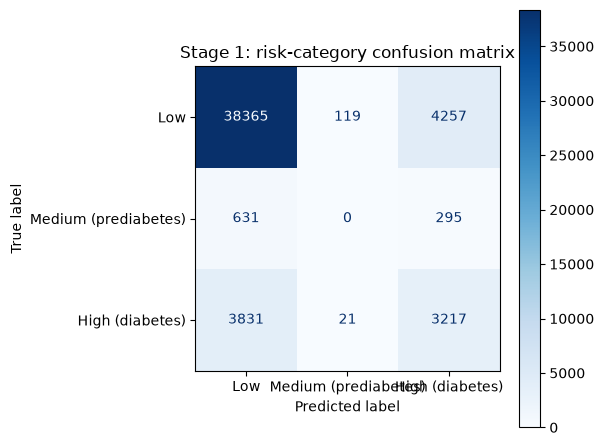

Training complete. Key metrics:
  accuracy: 0.8196
  balanced_accuracy: 0.4509
  macro_f1: 0.4434
  macro_ovr_roc_auc: 0.7582


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

model = RandomForestClassifier(
    n_estimators=400,
    class_weight='balanced_subsample',
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
model.fit(X_train, y_train)

predicted = model.predict(X_test)
probabilities = model.predict_proba(X_test)
metrics = {
    'n_rows': len(X),
    'n_train': len(X_train),
    'n_test': len(X_test),
    'class_counts': y.value_counts().sort_index().to_dict(),
    'accuracy': accuracy_score(y_test, predicted),
    'balanced_accuracy': balanced_accuracy_score(y_test, predicted),
    'macro_f1': f1_score(y_test, predicted, average='macro'),
    'weighted_f1': f1_score(y_test, predicted, average='weighted'),
    'macro_ovr_roc_auc': roc_auc_score(y_test, probabilities, multi_class='ovr', average='macro'),
    'classification_report': classification_report(
        y_test, predicted, labels=[0, 1, 2], target_names=[RISK_LABELS[i] for i in range(3)], output_dict=True
    ),
}

save_json = lambda value, path: Path(path).write_text(json.dumps(value, indent=2, default=lambda obj: obj.item() if isinstance(obj, (np.integer, np.floating)) else str(obj)), encoding='utf-8')
save_json(metrics, ARTIFACTS / 'metrics.json')
joblib.dump(model, ARTIFACTS / 'diabetes_risk_random_forest.joblib', compress=3)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, predicted, display_labels=list(RISK_LABELS.values()), cmap='Blues', ax=ax)
ax.set_title('Stage 1: risk-category confusion matrix')
fig.tight_layout()
fig.savefig(ARTIFACTS / 'confusion_matrix.png', dpi=180)
plt.show()

print('Training complete. Key metrics:')
for key in ('accuracy', 'balanced_accuracy', 'macro_f1', 'macro_ovr_roc_auc'):
    print(f'  {key}: {metrics[key]:.4f}')


## 4. Stage 1 evaluation (RQ1)

Use **macro-F1** and **balanced accuracy** as primary metrics because ordinary accuracy is distorted by class imbalance.

In [5]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)
metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
    'macro_f1': f1_score(y_test, y_pred, average='macro'),
    'weighted_f1': f1_score(y_test, y_pred, average='weighted'),
    'macro_ovr_roc_auc': roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro'),
}
pd.Series(metrics).to_frame('score').style.format('{:.4f}')

,score
accuracy,0.8196
balanced_accuracy,0.4509
macro_f1,0.4434
weighted_f1,0.8158
macro_ovr_roc_auc,0.7582


,precision,recall,f1-score,support
Low,0.896,0.898,0.897,42741.00
Medium (prediabetes),0.000,0.000,0.000,926.00
High (diabetes),0.414,0.455,0.434,7069.00
accuracy,0.820,0.820,0.820,0.82
macro avg,0.437,0.451,0.443,50736.00
weighted avg,0.812,0.820,0.816,50736.00


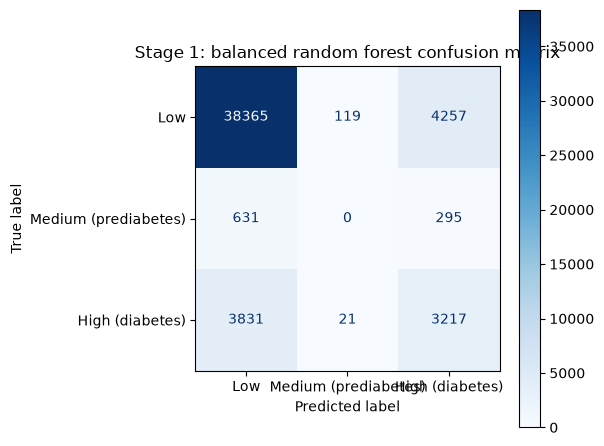

In [6]:
report = pd.DataFrame(classification_report(
    y_test, y_pred, labels=[0, 1, 2],
    target_names=[RISK_LABELS[i] for i in range(3)], output_dict=True
)).T
display(report.round(3))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=list(RISK_LABELS.values()), cmap='Blues', ax=ax
)
ax.set_title('Stage 1: balanced random forest confusion matrix')
fig.tight_layout()
fig.savefig(ARTIFACTS / 'confusion_matrix.png', dpi=180)
plt.show()

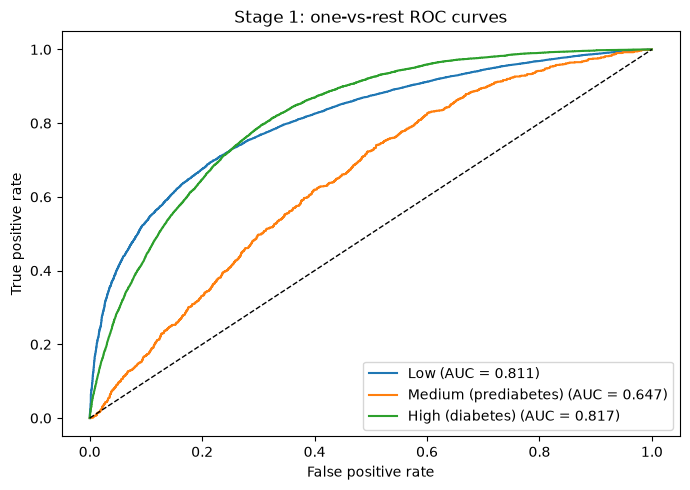

In [7]:
y_bin = label_binarize(y_test, classes=[0, 1, 2])
fig, ax = plt.subplots(figsize=(7, 5))
for class_id, label in RISK_LABELS.items():
    fpr, tpr, _ = roc_curve(y_bin[:, class_id], y_prob[:, class_id])
    ax.plot(fpr, tpr, label=f'{label} (AUC = {auc(fpr, tpr):.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set(xlabel='False positive rate', ylabel='True positive rate', title='Stage 1: one-vs-rest ROC curves')
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(ARTIFACTS / 'roc_curves.png', dpi=180)
plt.show()

## 5. Stage 2 global explanation (RQ2)

Permutation importance measures the decrease in held-out macro-F1 after shuffling one feature. It is more suitable for the report than in-sample tree impurity importance.

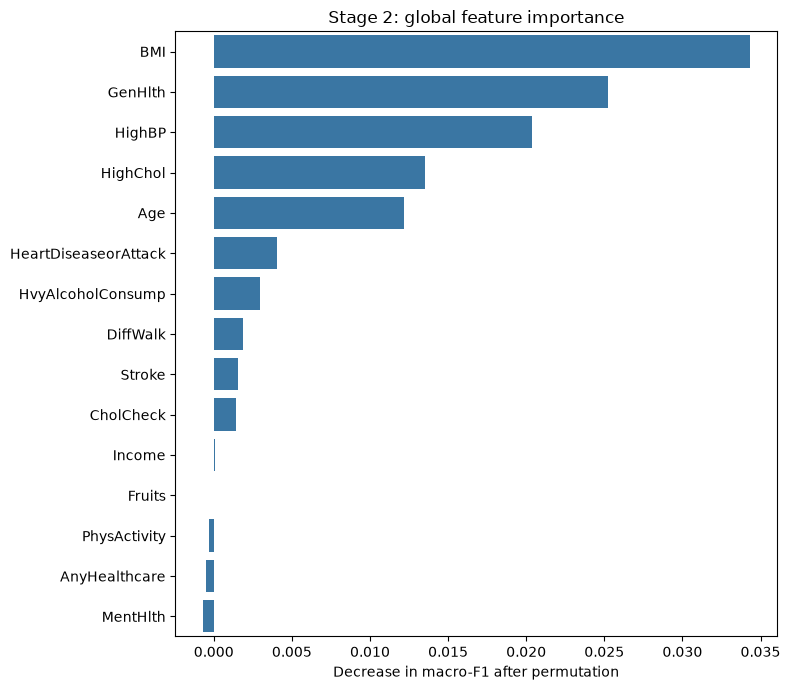

,feature,importance_mean,importance_std
3,BMI,0.034298,0.004960
13,GenHlth,0.025217,0.003590
0,HighBP,0.020348,0.003265
1,HighChol,0.013540,0.001911
18,Age,0.012206,0.004299
6,HeartDiseaseorAttack,0.004068,0.001351
10,HvyAlcoholConsump,0.002965,0.001111
16,DiffWalk,0.001893,0.001743
5,Stroke,0.001549,0.000701
2,CholCheck,0.001438,0.000584


In [8]:
# A held-out sample keeps this calculation practical while remaining reproducible.
importance_sample = X_test.sample(n=min(5000, len(X_test)), random_state=RANDOM_STATE)
importance_y = y_test.loc[importance_sample.index]
permutation = permutation_importance(
    model, importance_sample, importance_y, scoring='f1_macro',
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)
importance_df = pd.DataFrame({
    'feature': FEATURES,
    'importance_mean': permutation.importances_mean,
    'importance_std': permutation.importances_std,
}).sort_values('importance_mean', ascending=False)
importance_df.to_csv(ARTIFACTS / 'global_permutation_importance.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 7))
sns.barplot(data=importance_df.head(15), x='importance_mean', y='feature', color='#2878b5', ax=ax)
ax.set(xlabel='Decrease in macro-F1 after permutation', ylabel='', title='Stage 2: global feature importance')
fig.tight_layout()
fig.savefig(ARTIFACTS / 'global_feature_importance.png', dpi=180)
plt.show()
display(importance_df)

In [9]:
high_risk_test_indices = y_test[y_test == 2].index
patient_index = high_risk_test_indices[0]
patient = X_test.loc[[patient_index]]
patient_probabilities = model.predict_proba(patient)[0]
patient_prediction = int(model.predict(patient)[0])

print(f'Actual class: {RISK_LABELS[int(y_test.loc[patient_index])]}')
print(f'Predicted class: {RISK_LABELS[patient_prediction]}')
display(pd.Series(patient_probabilities, index=[RISK_LABELS[i] for i in model.classes_], name='probability').to_frame().style.format('{:.2%}'))
display(patient.T.rename(columns={patient_index: 'patient value'}))

Actual class: High (diabetes)
Predicted class: High (diabetes)


,probability
Low,38.47%
Medium (prediabetes),8.97%
High (diabetes),52.56%


,patient value
HighBP,0.0
HighChol,0.0
CholCheck,1.0
BMI,41.0
Smoker,1.0
Stroke,0.0
HeartDiseaseorAttack,0.0
PhysActivity,0.0
Fruits,0.0
Veggies,0.0


## 6. Save report-ready results

The resulting JSON is a compact record for the methodology/results chapter. Interpret macro-F1, balanced accuracy, and the Medium-class recall before claiming that RQ1 is answered.

In [10]:
results = {
    'dataset_rows': int(len(df)),
    'features': FEATURES,
    'class_counts': {RISK_LABELS[int(k)]: int(v) for k, v in y.value_counts().sort_index().items()},
    'metrics': {key: float(value) for key, value in metrics.items()},
    'classification_report': report.to_dict(),
    'top_global_features': importance_df.head(10).to_dict(orient='records'),
}
with open(ARTIFACTS / 'results_summary.json', 'w', encoding='utf-8') as file:
    json.dump(results, file, indent=2)
print(f'All notebook outputs saved in: {ARTIFACTS.resolve()}')

All notebook outputs saved in: C:\Users\user\OneDrive\Desktop\Swinb\Research\training3\artifacts_notebook


## 7. Stage 2 patient-level SHAP explanation

This selects a real held-out High-risk record. Change `patient_index` to explain a different test patient. A positive SHAP value supports the displayed predicted class; it does not establish clinical causality.

,feature,patient_value,shap_value,absolute_shap_value
3,BMI,41.0,0.118755,0.118755
0,HighBP,0.0,-0.085540,0.085540
13,GenHlth,4.0,0.084074,0.084074
16,DiffWalk,1.0,0.053306,0.053306
1,HighChol,0.0,-0.046587,0.046587
18,Age,9.0,0.041030,0.041030
14,MentHlth,10.0,-0.015580,0.015580
7,PhysActivity,0.0,0.013562,0.013562
19,Education,4.0,0.010911,0.010911
12,NoDocbcCost,0.0,0.009323,0.009323


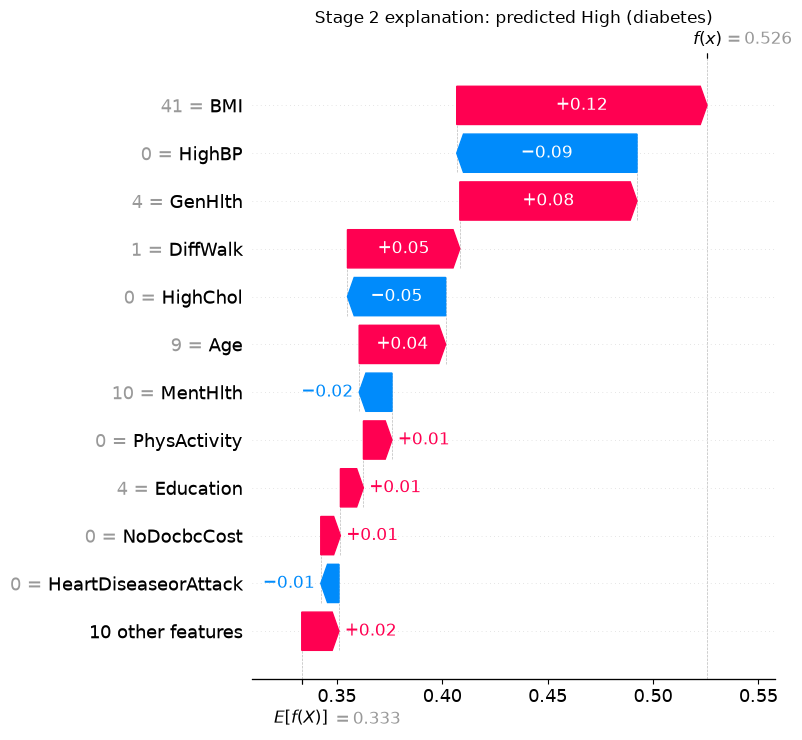

In [11]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(patient)
if isinstance(shap_values, list):
    selected_values = shap_values[patient_prediction][0]
else:
    selected_values = shap_values[0, :, patient_prediction]
base_values = explainer.expected_value[patient_prediction]

patient_shap = pd.DataFrame({
    'feature': FEATURES,
    'patient_value': patient.iloc[0].values,
    'shap_value': selected_values
})
patient_shap['absolute_shap_value'] = patient_shap['shap_value'].abs()
patient_shap = patient_shap.sort_values('absolute_shap_value', ascending=False)
patient_shap.to_csv(ARTIFACTS / 'patient_shap_contributions.csv', index=False)
display(patient_shap.head(10))

explanation = shap.Explanation(
    values=selected_values, base_values=base_values,
    data=patient.iloc[0].values, feature_names=FEATURES
)
shap.plots.waterfall(explanation, max_display=12, show=False)
plt.title(f'Stage 2 explanation: predicted {RISK_LABELS[patient_prediction]}')
plt.tight_layout()
plt.savefig(ARTIFACTS / 'patient_shap_waterfall.png', dpi=180, bbox_inches='tight')
plt.show()

## 8. Stage 3 patient-linked Digital Twin simulation (RQ3)

The baseline below is a real held-out row from the training dataset, not a hard-coded demonstration profile. Its one-based dataset patient number is printed so the same patient can be selected in the web dashboard.

Stage 3 manually changes a scenario and re-runs the same model. The result is an association under edited inputs, not evidence that an intervention causes the risk change.


In [15]:
# Use the held-out patient already selected for the Stage 2 local SHAP explanation.
dataset_patient_number = int(patient_index) + 1
current_values = {feature: float(patient.iloc[0][feature]) for feature in FEATURES}

def predict_profile(values):
    frame = pd.DataFrame([{feature: float(values[feature]) for feature in FEATURES}])
    probability_values = model.predict_proba(frame)[0]
    probability_by_class = {
        int(class_id): float(probability)
        for class_id, probability in zip(model.classes_, probability_values)
    }
    predicted_class = int(model.predict(frame)[0])
    return {
        "predicted_class": predicted_class,
        "label": RISK_LABELS[predicted_class],
        "high_risk_probability": probability_by_class.get(2, 0.0),
        "probabilities": probability_by_class,
    }

current_result = predict_profile(current_values)
print(f"Dataset patient number: {dataset_patient_number:,}")
print(f"Recorded class: {RISK_LABELS[int(y.loc[patient_index])]}")
print(f"Predicted class: {current_result['label']}")
print(f"High-diabetes probability: {current_result['high_risk_probability']:.1%}")
display(pd.Series(current_values, name="current value").to_frame())


Dataset patient number: 104,917
Recorded class: High (diabetes)
Predicted class: High (diabetes)
High-diabetes probability: 52.6%


,current value
HighBP,0.0
HighChol,0.0
CholCheck,1.0
BMI,41.0
Smoker,1.0
Stroke,0.0
HeartDiseaseorAttack,0.0
PhysActivity,0.0
Fruits,0.0
Veggies,0.0


In [16]:
# Define one transparent, reproducible manual scenario.
scenario_values = current_values.copy()
scenario_values["BMI"] = max(12.0, current_values["BMI"] - 5.0)
scenario_values["PhysActivity"] = 1.0

scenario_result = predict_profile(scenario_values)
changes = [
    {"feature": feature, "current": current_values[feature], "scenario": scenario_values[feature]}
    for feature in FEATURES
    if current_values[feature] != scenario_values[feature]
]
comparison = pd.DataFrame([
    {
        "state": "Current dataset patient",
        "predicted class": current_result["label"],
        "high-diabetes probability": current_result["high_risk_probability"],
    },
    {
        "state": "Manual scenario",
        "predicted class": scenario_result["label"],
        "high-diabetes probability": scenario_result["high_risk_probability"],
    },
]).set_index("state")

display(pd.DataFrame(changes))
display(comparison.style.format({"high-diabetes probability": "{:.1%}"}))
print(
    "Model-estimated change: "
    f"{(scenario_result['high_risk_probability'] - current_result['high_risk_probability']) * 100:+.1f} percentage points"
)


,feature,current,scenario
0,BMI,41.0,36.0
1,PhysActivity,0.0,1.0


,predicted class,high-diabetes probability
state,,
Current dataset patient,High (diabetes),52.6%
Manual scenario,Low,42.1%


Model-estimated change: -10.5 percentage points


### Stage 3 virtual-patient parameters

The current implementation maps BMI to the first SMPL shape coefficient and maps the model probability to a risk colour. The dashboard regenerates the GLB mesh from the selected dataset patient when Docker and the licensed local SMPL weights are available.


In [17]:
def smpl_descriptor(values, prediction):
    risk_percent = float(prediction["high_risk_probability"]) * 100
    if risk_percent > 70:
        colour, band = "#FF4D4D", "High"
    elif risk_percent >= 40:
        colour, band = "#FFA500", "Moderate"
    else:
        colour, band = "#2ECC71", "Low"
    return {
        "dataset_patient_number": dataset_patient_number,
        "bmi": float(values["BMI"]),
        "gender": "male" if int(values["Sex"]) == 1 else "female",
        "smpl_beta_0": (float(values["BMI"]) - 22.0) * 0.5,
        "risk_percent": risk_percent,
        "risk_band": band,
        "risk_colour": colour,
    }

current_twin = smpl_descriptor(current_values, current_result)
scenario_twin = smpl_descriptor(scenario_values, scenario_result)
display(pd.DataFrame([current_twin, scenario_twin], index=["Current", "Scenario"]).T)

stage3_case_study = {
    "current": current_twin,
    "scenario": scenario_twin,
    "edited_features": changes,
    "important_limitation": (
        "This is model re-prediction after manual input edits; it is not a causal "
        "estimate or treatment recommendation."
    ),
}
with open(ARTIFACTS / "stage3_case_study.json", "w", encoding="utf-8") as file:
    json.dump(stage3_case_study, file, indent=2)
print(f"Saved: {ARTIFACTS / 'stage3_case_study.json'}")


,Current,Scenario
dataset_patient_number,104917,104917
bmi,41.0,36.0
gender,female,female
smpl_beta_0,9.5,7.0
risk_percent,52.560952,42.09062
risk_band,Moderate,Moderate
risk_colour,#FFA500,#FFA500


Saved: artifacts_notebook\stage3_case_study.json


## 9. Alignment with the project stages

| Stage | Implemented in this notebook | Evidence produced |
|---|---|---|
| 1 - Prediction | Yes | Held-out metrics, confusion matrix, ROC curves |
| 2 - Explanation | Yes | Permutation importance and patient-level SHAP |
| 3 - Manual Digital Twin simulation | Yes | Dataset-linked current patient, edited scenario, updated model estimate, SMPL parameters |
| 4 - Knowledge Graph-driven Digital Twin | No | Neo4j reasoning and automatic intervention generation remain future work |

The current BRFSS dataset is cross-sectional and does not contain HbA1c or MeanCGM. It therefore cannot support the proposal's longitudinal ShanghaiT2DM claims or examples involving those clinical measurements.
